# Analiza strategije guma u Formuli 1

Ovaj notebook prikazuje kompletan tok projekta: od prikupljanja i obrade podataka, preko primene modela, do evaluacije i interpretacije rezultata.

Cilj analize je da se razume izbor smese guma i da se uporede performanse modela klasifikacije i klasterovanja na realnim F1 podacima.


## 1. Učitavanje biblioteka i putanja

U ovom delu pripremamo okruženje i putanje do ulaznih podataka i izlaznih rezultata.
Time obezbeđujemo da se svaki sledeći korak izvršava nad istim lokacijama fajlova i da je ceo tok reproduktivan.


In [37]:
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data_collection import CollectionConfig, collect_race_laps
from src.preprocessing import preprocess_laps
from src.modeling import evaluate_classification_models, evaluate_clustering_models
from src.run_pipeline import run_pipeline

raw_path = PROJECT_ROOT / "data/raw/f1_laps_raw.csv"
processed_path = PROJECT_ROOT / "data/processed/f1_laps_processed.csv"
results_path = PROJECT_ROOT / "results"

raw_path.parent.mkdir(parents=True, exist_ok=True)
processed_path.parent.mkdir(parents=True, exist_ok=True)
results_path.mkdir(parents=True, exist_ok=True)

run_history_path = results_path / "run_history.csv"
latest_pipeline_run_id = None
if run_history_path.exists():
    run_history_df = pd.read_csv(run_history_path)
    if not run_history_df.empty and "run_timestamp" in run_history_df.columns:
        run_history_df["run_timestamp"] = pd.to_datetime(run_history_df["run_timestamp"], errors="coerce")
        latest_pipeline_run_id = run_history_df.sort_values("run_timestamp").iloc[-1]["run_id"]
print(f"Poslednji pipeline run_id: {latest_pipeline_run_id}")

# Oficijalne F1 boje guma
COMPOUND_COLORS = {"SOFT": "#DA291C", "MEDIUM": "#FFC906", "HARD": "#FFFFFF"}
COMPOUND_COLORS_PLOT = {"SOFT": "#DA291C", "MEDIUM": "#FFC906", "HARD": "#A0A0A0"}  # siva umesto bele za vidljivost na grafiku

# Oficijalne F1 boje timova (2024-2025 sezona)
TEAM_COLORS = {
    "Red Bull": "#3671C6",
    "Mercedes": "#27F4D2",
    "Ferrari": "#E8002D",
    "McLaren": "#FF8000",
    "Aston Martin": "#229971",
    "Alpine": "#FF87BC",
    "Williams": "#64C4FF",
    "RB": "#6692FF",
    "Sauber": "#52E252",
    "Haas": "#B6BABD",
}

Poslednji pipeline run_id: 20260329T205938455526Z


## 2. Prikupljanje podataka (2019-2025)

Prikupljaju se podaci o krugovima sa trka Formule 1 za period 2019-2025.
U izlazu dobijamo sirov skup podataka koji predstavlja osnovu za dalju obradu i modelovanje.


In [2]:
config = CollectionConfig(start_year=2019, end_year=2025, cache_dir=PROJECT_ROOT / "data/cache")
raw_laps = collect_race_laps(config)
raw_laps.to_csv(raw_path, index=False)

print(f"Učitano krugova (sirovi podaci): {len(raw_laps)}")
raw_laps

core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Driver 77 completed the race distance 00:00.387000 before the recorded end of the session.
core           INFO 	Finished loading data for 20 drivers: ['77', '44', '33', '5', '16', '20', '27', '7', '18', '26', '10', '4', '11', '23', '99', '63', '88', '8', '3', '55']
core           INFO 	Loading data for British Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver

Učitano krugova (sirovi podaci): 167083


,Driver,Team,LapNumber,TyreLife,Compound,LapTime,Sector1Time,Sector2Time,Sector3Time,SpeedI1,...,TrackStatus,PitOutTime,PitInTime,IsAccurate,Year,RoundNumber,EventName,Country,Location,OfficialEventName
0,GAS,Red Bull Racing,1.0,1.0,MEDIUM,0 days 00:01:45.008000,NaT,0 days 00:00:24.917000,0 days 00:00:38.018000,253.0,...,12,NaT,NaT,False,2019,1,Australian Grand Prix,Australia,Melbourne,FORMULA 1 ROLEX AUSTRALIAN GRAND PRIX 2019
1,GAS,Red Bull Racing,2.0,2.0,MEDIUM,0 days 00:01:31.585000,0 days 00:00:30.704000,0 days 00:00:24.245000,0 days 00:00:36.636000,266.0,...,1,NaT,NaT,True,2019,1,Australian Grand Prix,Australia,Melbourne,FORMULA 1 ROLEX AUSTRALIAN GRAND PRIX 2019
2,GAS,Red Bull Racing,3.0,3.0,MEDIUM,0 days 00:01:31.406000,0 days 00:00:30.920000,0 days 00:00:24.387000,0 days 00:00:36.099000,268.0,...,1,NaT,NaT,True,2019,1,Australian Grand Prix,Australia,Melbourne,FORMULA 1 ROLEX AUSTRALIAN GRAND PRIX 2019
3,GAS,Red Bull Racing,4.0,4.0,MEDIUM,0 days 00:01:32.361000,0 days 00:00:32.196000,0 days 00:00:24.238000,0 days 00:00:35.927000,261.0,...,1,NaT,NaT,True,2019,1,Australian Grand Prix,Australia,Melbourne,FORMULA 1 ROLEX AUSTRALIAN GRAND PRIX 2019
4,GAS,Red Bull Racing,5.0,5.0,MEDIUM,0 days 00:01:31.171000,0 days 00:00:30.366000,0 days 00:00:24.301000,0 days 00:00:36.504000,266.0,...,1,NaT,NaT,True,2019,1,Australian Grand Prix,Australia,Melbourne,FORMULA 1 ROLEX AUSTRALIAN GRAND PRIX 2019
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
167078,BEA,Haas F1 Team,62.0,14.0,SOFT,0 days 00:01:20.255000,0 days 00:00:23.593000,0 days 00:00:32.490000,0 days 00:00:24.172000,274.0,...,1,NaT,NaT,True,2025,9,Spanish Grand Prix,Spain,Barcelona,FORMULA 1 ARAMCO GRAN PREMIO DE ESPAÑA 2025
167079,BEA,Haas F1 Team,63.0,15.0,SOFT,0 days 00:01:18.907000,0 days 00:00:22.884000,0 days 00:00:32.034000,0 days 00:00:23.989000,275.0,...,1,NaT,NaT,True,2025,9,Spanish Grand Prix,Spain,Barcelona,FORMULA 1 ARAMCO GRAN PREMIO DE ESPAÑA 2025
167080,BEA,Haas F1 Team,64.0,16.0,SOFT,0 days 00:01:20.300000,0 days 00:00:23.498000,0 days 00:00:32.736000,0 days 00:00:24.066000,274.0,...,1,NaT,NaT,True,2025,9,Spanish Grand Prix,Spain,Barcelona,FORMULA 1 ARAMCO GRAN PREMIO DE ESPAÑA 2025
167081,BEA,Haas F1 Team,65.0,17.0,SOFT,0 days 00:01:20.082000,0 days 00:00:23.363000,0 days 00:00:32.711000,0 days 00:00:24.008000,276.0,...,1,NaT,NaT,True,2025,9,Spanish Grand Prix,Spain,Barcelona,FORMULA 1 ARAMCO GRAN PREMIO DE ESPAÑA 2025


## 3. Transformacija i filtriranje podataka

Sirovi podaci se čiste i prevode u oblik pogodan za modelovanje: vremenske kolone se standardizuju, formiraju se ključna obeležja i uklanjaju tehnički nevalidni zapisi.

U ovoj fazi radimo baznu obradu (`preprocess_laps`). IQR outlier filtriranje se radi kasnije u modelingu na train delu skupa, a isti pragovi se zatim primenjuju na validation/test.


In [3]:
processed_laps = preprocess_laps(raw_laps)
processed_laps.to_csv(processed_path, index=False)

print(f"Broj krugova nakon obrade: {len(processed_laps)}")
processed_laps

/Users/zoranbukorac/Desktop/PythonProjects/F1-Strategy-Analyses/src/preprocessing.py:96: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["LapNumber"] = pd.to_numeric(df["LapNumber"], errors="coerce")
/Users/zoranbukorac/Desktop/PythonProjects/F1-Strategy-Analyses/src/preprocessing.py:149: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["SectorRatio_S1"] = df["Sector1Time"] / df["LapTime"]
/Users/zoranbukorac/Desktop/PythonProjects/F1-Strategy-Analyses/src/preprocessing.py:150: SettingWithCopyWarning: 
A v

Broj krugova nakon obrade: 135672


,Year,RoundNumber,EventName,Country,Location,Driver,Team,CanonicalTeam,LapNumber,TyreLife,...,Sector2Time,Sector3Time,MaxSpeed,AvgSpeed,SectorRatio_S1,SectorRatio_S2,SectorRatio_S3,SpeedDelta,TyreLifeSquared,LapFraction
0,2019,1,Australian Grand Prix,Australia,Melbourne,ALB,Toro Rosso,RB,2.0,2.0,...,24.179,36.717,289.0,283.25,0.336037,0.263629,0.400334,5.75,4.0,0.034483
1,2019,1,Australian Grand Prix,Australia,Melbourne,ALB,Toro Rosso,RB,3.0,3.0,...,24.212,36.432,291.0,282.75,0.336187,0.265026,0.398787,8.25,9.0,0.051724
2,2019,1,Australian Grand Prix,Australia,Melbourne,ALB,Toro Rosso,RB,4.0,4.0,...,24.304,36.682,296.0,283.50,0.332910,0.265847,0.401243,12.50,16.0,0.068966
3,2019,1,Australian Grand Prix,Australia,Melbourne,ALB,Toro Rosso,RB,5.0,5.0,...,24.085,36.411,294.0,283.00,0.334360,0.265008,0.400632,11.00,25.0,0.086207
4,2019,1,Australian Grand Prix,Australia,Melbourne,ALB,Toro Rosso,RB,6.0,6.0,...,24.164,36.700,292.0,282.50,0.334631,0.264162,0.401207,9.50,36.0,0.103448
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135667,2025,24,Abu Dhabi Grand Prix,United Arab Emirates,Yas Island,VER,Red Bull Racing,Red Bull,54.0,31.0,...,38.408,32.186,307.0,278.00,0.199388,0.435588,0.365024,29.00,961.0,0.931034
135668,2025,24,Abu Dhabi Grand Prix,United Arab Emirates,Yas Island,VER,Red Bull Racing,Red Bull,55.0,32.0,...,38.594,32.651,306.0,275.75,0.197845,0.434534,0.367621,30.25,1024.0,0.948276
135669,2025,24,Abu Dhabi Grand Prix,United Arab Emirates,Yas Island,VER,Red Bull Racing,Red Bull,56.0,33.0,...,38.458,32.624,305.0,276.75,0.197910,0.433960,0.368129,28.25,1089.0,0.965517
135670,2025,24,Abu Dhabi Grand Prix,United Arab Emirates,Yas Island,VER,Red Bull Racing,Red Bull,57.0,34.0,...,38.444,32.640,310.0,278.50,0.199342,0.433016,0.367642,31.50,1156.0,0.982759


## 4. Vizualizacija podataka

Prikazuju se osnovne karakteristike skupa: raspodela tipova guma, raspodela vremena kruga i odnosi ključnih obeležja.
Cilj je da se pre modelovanja vidi struktura podataka i potencijalne razlike između klasa.


In [4]:
compound_counts = processed_laps["Compound"].astype(str).value_counts()
compound_counts

Compound
HARD      61457
MEDIUM    53080
SOFT      21135
Name: count, dtype: int64

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
sorted_compounds = compound_counts.sort_index()
bar_colors = [COMPOUND_COLORS_PLOT[c] for c in sorted_compounds.index]
sorted_compounds.plot(kind="bar", ax=ax, color=bar_colors, edgecolor="black", linewidth=0.5)
ax.set_title("Raspodela tipova guma")
ax.set_xlabel("Tip gume")
ax.set_ylabel("Broj krugova")
plt.tight_layout()

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
for compound in ["SOFT", "MEDIUM", "HARD"]:
    subset = processed_laps.loc[processed_laps["Compound"].astype(str) == compound, "LapTime"]
    if not subset.empty:
        ax.hist(subset, bins=50, alpha=0.45, label=compound, color=COMPOUND_COLORS_PLOT[compound],
                edgecolor="black", linewidth=0.3)

ax.set_title("Distribucija vremena kruga po tipu gume")
ax.set_xlabel("Vreme kruga (s)")
ax.set_ylabel("Broj krugova")
ax.legend()
plt.tight_layout()

In [ ]:
top_teams = processed_laps["CanonicalTeam"].astype(str).value_counts().head(10).index
box_data = [processed_laps.loc[processed_laps["CanonicalTeam"].astype(str) == team, "LapTime"].values for team in top_teams]

fig, ax = plt.subplots(figsize=(10, 5))
bp = ax.boxplot(box_data, tick_labels=top_teams, showfliers=False, patch_artist=True)
for patch, team in zip(bp["boxes"], top_teams):
    patch.set_facecolor(TEAM_COLORS.get(team, "#CCCCCC"))
    patch.set_edgecolor("black")
    patch.set_linewidth(0.5)
    patch.set_alpha(0.8)

ax.set_title("Vreme kruga po kanonskom timu (bez outlier-a)")
ax.set_xlabel("Tim")
ax.set_ylabel("Vreme kruga (s)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

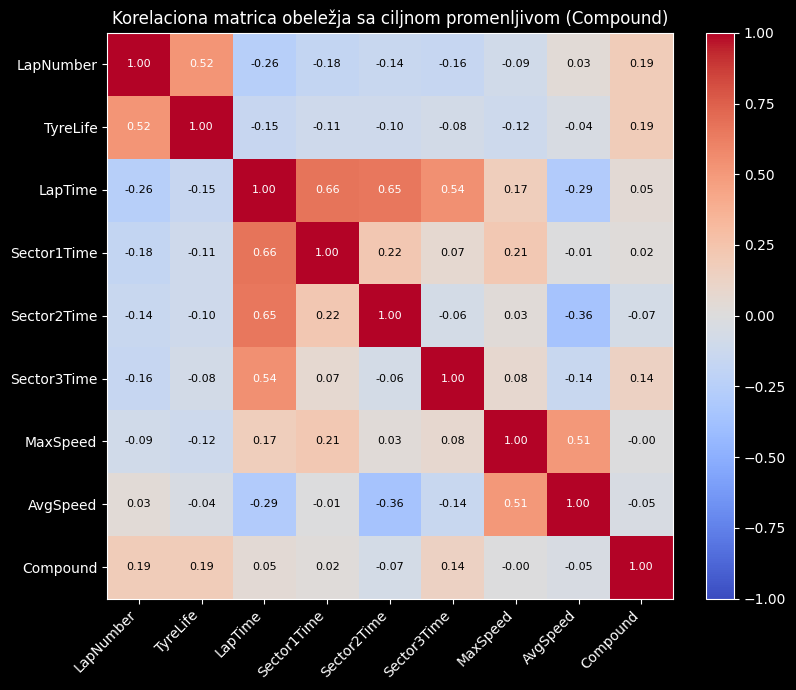

In [8]:
compound_map = {"SOFT": 0, "MEDIUM": 1, "HARD": 2}
corr_df = processed_laps.copy()
corr_df["Compound_encoded"] = corr_df["Compound"].astype(str).map(compound_map)

corr_cols = ["LapNumber", "TyreLife", "LapTime", "Sector1Time", "Sector2Time", "Sector3Time", "MaxSpeed", "AvgSpeed", "Compound_encoded"]
display_labels = [c if c != "Compound_encoded" else "Compound" for c in corr_cols]
corr = corr_df[corr_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr.values, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(np.arange(len(corr_cols)))
ax.set_yticks(np.arange(len(corr_cols)))
ax.set_xticklabels(display_labels, rotation=45, ha="right")
ax.set_yticklabels(display_labels)

for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center",
                color="white" if abs(corr.values[i, j]) > 0.5 else "black", fontsize=8)

ax.set_title("Korelaciona matrica obeležja sa ciljnom promenljivom (Compound)")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()

### 4.1 Normalizovani podaci po tipu gume (z-score po trci)

Z-score normalizacija po trci uklanja razlike u karakteristikama staza i omogućava smisleno poređenje performansi različitih smesa guma.

In [ ]:
normalize_cols = ["LapTime", "Sector1Time", "Sector2Time", "Sector3Time", "MaxSpeed", "AvgSpeed"]
norm_df = processed_laps.copy()

for col in normalize_cols:
    group_mean = norm_df.groupby(["Year", "EventName"])[col].transform("mean")
    group_std = norm_df.groupby(["Year", "EventName"])[col].transform("std")
    norm_df[f"{col}_zscore"] = (norm_df[col] - group_mean) / group_std

norm_df = norm_df.fillna({f"{col}_zscore": 0 for col in normalize_cols})

compounds = ["SOFT", "MEDIUM", "HARD"]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for idx, col in enumerate(normalize_cols):
    ax = axes[idx // 3][idx % 3]
    data_by_compound = [
        norm_df.loc[norm_df["Compound"].astype(str) == c, f"{col}_zscore"].dropna()
        for c in compounds
    ]
    bp = ax.boxplot(data_by_compound, labels=compounds, showfliers=False, patch_artist=True)
    for patch, c in zip(bp["boxes"], compounds):
        patch.set_facecolor(COMPOUND_COLORS_PLOT[c])
        patch.set_edgecolor("black")
        patch.set_linewidth(0.5)
        patch.set_alpha(0.7)
    ax.set_title(f"{col} (z-score)")
    ax.set_ylabel("Z-score")
    ax.axhline(y=0, color="gray", linestyle="--", alpha=0.5)

fig.suptitle("Normalizovane performanse po tipu gume (z-score po trci)", fontsize=14)
plt.tight_layout()

### 4.2 Degradacija guma tokom stinta

Prosečno normalizovano vreme kruga u zavisnosti od starosti gume (TyreLife) po tipu smese.
Normalizacija po trci (z-score) uklanja razlike u stazama i prikazuje čist efekat degradacije.

In [ ]:
deg_df = processed_laps.copy()
group_mean = deg_df.groupby(["Year", "EventName"])["LapTime"].transform("mean")
group_std = deg_df.groupby(["Year", "EventName"])["LapTime"].transform("std")
deg_df["LapTime_zscore"] = (deg_df["LapTime"] - group_mean) / group_std
deg_df = deg_df.dropna(subset=["LapTime_zscore"])

max_tyre_life = 40
deg_df = deg_df[deg_df["TyreLife"] <= max_tyre_life]

compounds = ["SOFT", "MEDIUM", "HARD"]

fig, ax = plt.subplots(figsize=(10, 5))
for compound in compounds:
    subset = deg_df[deg_df["Compound"].astype(str) == compound]
    avg_by_life = subset.groupby("TyreLife")["LapTime_zscore"].mean()
    ax.plot(avg_by_life.index, avg_by_life.values, label=compound,
            color=COMPOUND_COLORS_PLOT[compound], linewidth=2)
    ci = subset.groupby("TyreLife")["LapTime_zscore"].std()
    ax.fill_between(avg_by_life.index,
                    avg_by_life.values - ci.values,
                    avg_by_life.values + ci.values,
                    color=COMPOUND_COLORS_PLOT[compound], alpha=0.15)

ax.set_xlabel("Starost gume (broj krugova)")
ax.set_ylabel("Normalizovano vreme kruga (z-score)")
ax.set_title("Degradacija guma — prosečno vreme kruga po starosti gume")
ax.legend(title="Smesa")
ax.axhline(y=0, color="gray", linestyle="--", alpha=0.5)
ax.set_xlim(1, max_tyre_life)
plt.tight_layout()

### 4.3 Scatter matrica ključnih obeležja po tipu gume

Scatter plot matrica prikazuje odnose između parova najvažnijih obeležja, obojena po tipu gume.
Ovo omogućava uvid u to koje kombinacije obeležja najbolje razdvajaju klase pre primene modela.

In [ ]:
pair_cols = ["TyreLife", "LapTime", "AvgSpeed", "MaxSpeed"]
compounds = ["SOFT", "MEDIUM", "HARD"]

sample_df = processed_laps.dropna(subset=pair_cols + ["Compound"]).copy()
sample_df["Compound_str"] = sample_df["Compound"].astype(str)
sample_df = sample_df[sample_df["Compound_str"].isin(compounds)]
sample_df = sample_df.sample(n=min(15000, len(sample_df)), random_state=42)

n = len(pair_cols)
fig, axes = plt.subplots(n, n, figsize=(14, 14))

for i in range(n):
    for j in range(n):
        ax = axes[i][j]
        if i == j:
            for compound in compounds:
                subset = sample_df[sample_df["Compound_str"] == compound]
                ax.hist(subset[pair_cols[i]], bins=30, alpha=0.5,
                        color=COMPOUND_COLORS_PLOT[compound], label=compound, density=True)
            if i == 0:
                ax.legend(fontsize=8)
        else:
            for compound in compounds:
                subset = sample_df[sample_df["Compound_str"] == compound]
                ax.scatter(subset[pair_cols[j]], subset[pair_cols[i]],
                           c=COMPOUND_COLORS_PLOT[compound], alpha=0.15, s=3, label=compound)

        if i == n - 1:
            ax.set_xlabel(pair_cols[j], fontsize=9)
        else:
            ax.set_xticklabels([])
        if j == 0:
            ax.set_ylabel(pair_cols[i], fontsize=9)
        else:
            ax.set_yticklabels([])

fig.suptitle("Scatter matrica ključnih obeležja po tipu gume", fontsize=14, y=1.01)
plt.tight_layout()

### 4.4 Distribucija dužine stinta po tipu gume

Koliko krugova se tipično vozi na svakom tipu gume pre zamene.
Ovo objašnjava nebalansiranost klasa — HARD gume imaju najviše krugova jer se koriste u najdužim stintovima.

In [ ]:
compounds = ["SOFT", "MEDIUM", "HARD"]

fig, ax = plt.subplots(figsize=(10, 5))
for compound in compounds:
    subset = processed_laps[processed_laps["Compound"].astype(str) == compound]["TyreLife"]
    ax.hist(subset, bins=range(1, 51), alpha=0.5, color=COMPOUND_COLORS_PLOT[compound],
            label=f"{compound} (medijana: {subset.median():.0f})", density=True, edgecolor="white")

ax.set_xlabel("Starost gume (broj krugova)")
ax.set_ylabel("Gustina")
ax.set_title("Distribucija dužine stinta po tipu gume")
ax.legend()
ax.set_xlim(1, 50)
plt.tight_layout()

### 4.5 Korišćenje smesa tokom trke

Udeo svake smese guma u zavisnosti od broja kruga (grupisano po 5 krugova).
Prikazuje tipične strateške obrasce — na primer, SOFT se najčešće koristi na početku trke, a HARD u drugom delu.

In [ ]:
compounds = ["SOFT", "MEDIUM", "HARD"]

race_df = processed_laps[processed_laps["LapNumber"] <= 70].copy()
race_df["LapBin"] = (race_df["LapNumber"] // 5) * 5
race_df["Compound_str"] = race_df["Compound"].astype(str)

ct = pd.crosstab(race_df["LapBin"], race_df["Compound_str"], normalize="index")
ct = ct.reindex(columns=[c for c in compounds if c in ct.columns])

fig, ax = plt.subplots(figsize=(12, 5))
ct.plot.area(ax=ax, stacked=True, color=[COMPOUND_COLORS_PLOT[c] for c in ct.columns], alpha=0.8)
ax.set_xlabel("Broj kruga (grupisano po 5)")
ax.set_ylabel("Udeo smese")
ax.set_title("Udeo smesa guma tokom trke")
ax.set_ylim(0, 1)
ax.legend(title="Smesa", loc="center right")
plt.tight_layout()

### 4.6 Trendovi po sezonama (2019-2025)

Levi grafik prikazuje kako se udeo svake smese menjao po sezonama.
Desni grafik prikazuje prosečno normalizovano vreme kruga po sezoni i smesi — pokazuje da li se relativne performanse smesa menjaju iz godine u godinu.

In [ ]:
compounds = ["SOFT", "MEDIUM", "HARD"]

season_df = processed_laps.copy()
season_df["Compound_str"] = season_df["Compound"].astype(str)

# Left: compound proportions per year
ct_year = pd.crosstab(season_df["Year"], season_df["Compound_str"], normalize="index")
ct_year = ct_year.reindex(columns=[c for c in compounds if c in ct_year.columns])

# Right: normalized lap time per year and compound
group_mean = season_df.groupby(["Year", "EventName"])["LapTime"].transform("mean")
group_std = season_df.groupby(["Year", "EventName"])["LapTime"].transform("std")
season_df["LapTime_zscore"] = (season_df["LapTime"] - group_mean) / group_std
season_df = season_df.dropna(subset=["LapTime_zscore"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ct_year.plot.bar(ax=axes[0], stacked=True, color=[COMPOUND_COLORS_PLOT[c] for c in ct_year.columns], alpha=0.8)
axes[0].set_xlabel("Sezona")
axes[0].set_ylabel("Udeo smese")
axes[0].set_title("Udeo smesa po sezonama")
axes[0].legend(title="Smesa")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis="x", rotation=45)

for compound in compounds:
    subset = season_df[season_df["Compound_str"] == compound]
    yearly_mean = subset.groupby("Year")["LapTime_zscore"].mean()
    axes[1].plot(yearly_mean.index, yearly_mean.values, "o-",
                 label=compound, color=COMPOUND_COLORS_PLOT[compound], linewidth=2)

axes[1].set_xlabel("Sezona")
axes[1].set_ylabel("Prosečno normalizovano vreme (z-score)")
axes[1].set_title("Relativne performanse smesa po sezonama")
axes[1].legend(title="Smesa")
axes[1].axhline(y=0, color="gray", linestyle="--", alpha=0.5)

plt.tight_layout()

### 4.7 Preferencija smesa po stazi

Toplotna mapa prikazuje udeo svake smese guma po stazi (top 15 staza po broju krugova).
Staze sa visokom degradacijom imaju veći udeo HARD guma, dok staze sa niskom degradacijom favorizuju SOFT.

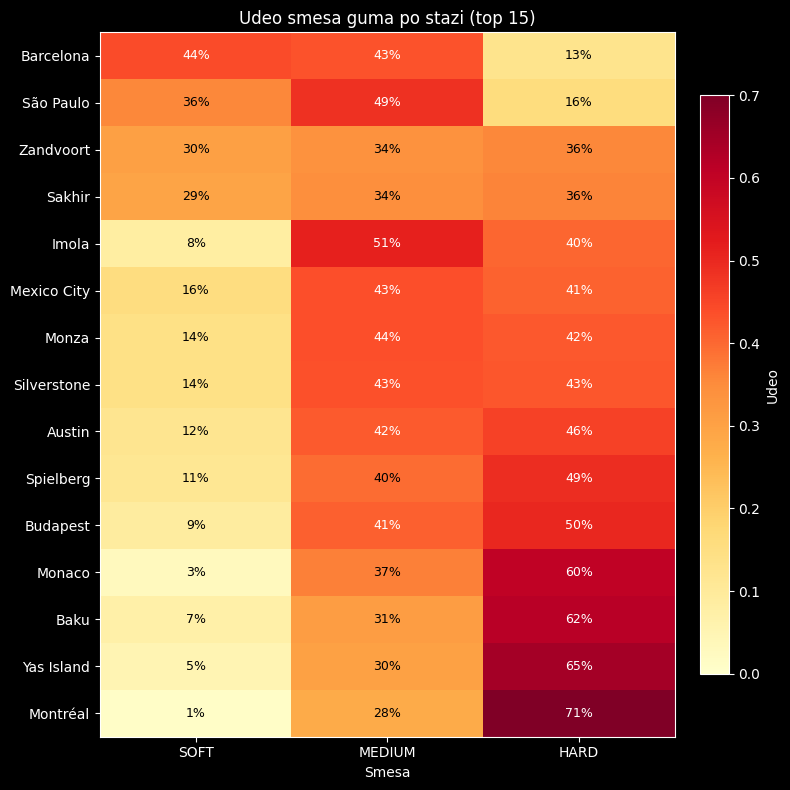

In [15]:
compounds = ["SOFT", "MEDIUM", "HARD"]

track_df = processed_laps.copy()
track_df["Compound_str"] = track_df["Compound"].astype(str)

top_tracks = track_df["Location"].value_counts().head(15).index
track_subset = track_df[track_df["Location"].isin(top_tracks)]

ct_track = pd.crosstab(track_subset["Location"], track_subset["Compound_str"], normalize="index")
ct_track = ct_track.reindex(columns=[c for c in compounds if c in ct_track.columns])
ct_track = ct_track.sort_values("HARD", ascending=True)

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(ct_track.values, cmap="YlOrRd", aspect="auto", vmin=0, vmax=0.7)
ax.set_xticks(np.arange(len(ct_track.columns)))
ax.set_yticks(np.arange(len(ct_track.index)))
ax.set_xticklabels(ct_track.columns)
ax.set_yticklabels(ct_track.index)

for i in range(len(ct_track.index)):
    for j in range(len(ct_track.columns)):
        val = ct_track.values[i, j]
        color = "white" if val > 0.4 else "black"
        ax.text(j, i, f"{val:.0%}", ha="center", va="center", color=color, fontsize=9)

ax.set_xlabel("Smesa")
ax.set_title("Udeo smesa guma po stazi (top 15)")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Udeo")
plt.tight_layout()

## 5. Klasifikacija tipa gume

U ovom delu modeli predviđaju tip gume (`SOFT`, `MEDIUM`, `HARD`) na osnovu karakteristika kruga.
Evaluacija se radi na validation i test delu, kako bi prikazane metrike odražavale generalizaciju modela.


In [16]:
classification_metrics = evaluate_classification_models(
    processed_laps,
    output_dir=results_path / "classification",
    random_state=42,
)
classification_metrics

,run_id,run_timestamp,model,split,macro_f1,weighted_f1,model_params
0,20260329T212037959283Z,2026-03-29T21:20:37Z,RandomForest,validation,0.784783,0.801354,"{""bootstrap"": true, ""ccp_alpha"": 0.0, ""class_w..."
1,20260329T212037959283Z,2026-03-29T21:20:37Z,RandomForest,test,0.781094,0.800157,"{""bootstrap"": true, ""ccp_alpha"": 0.0, ""class_w..."
2,20260329T212037959283Z,2026-03-29T21:20:37Z,XGBoost,validation,0.792999,0.805025,"{""base_score"": null, ""booster"": null, ""callbac..."
3,20260329T212037959283Z,2026-03-29T21:20:37Z,XGBoost,test,0.789683,0.803265,"{""base_score"": null, ""booster"": null, ""callbac..."


In [17]:
classification_metrics_latest = classification_metrics.copy()
latest_classification_run_id = classification_metrics["run_id"].iloc[0] if "run_id" in classification_metrics.columns else None

print(f"Run klasifikacije: {latest_classification_run_id}")
classification_metrics_latest

Run klasifikacije: 20260329T212037959283Z


,run_id,run_timestamp,model,split,macro_f1,weighted_f1,model_params
0,20260329T212037959283Z,2026-03-29T21:20:37Z,RandomForest,validation,0.784783,0.801354,"{""bootstrap"": true, ""ccp_alpha"": 0.0, ""class_w..."
1,20260329T212037959283Z,2026-03-29T21:20:37Z,RandomForest,test,0.781094,0.800157,"{""bootstrap"": true, ""ccp_alpha"": 0.0, ""class_w..."
2,20260329T212037959283Z,2026-03-29T21:20:37Z,XGBoost,validation,0.792999,0.805025,"{""base_score"": null, ""booster"": null, ""callbac..."
3,20260329T212037959283Z,2026-03-29T21:20:37Z,XGBoost,test,0.789683,0.803265,"{""base_score"": null, ""booster"": null, ""callbac..."


### 5.1 Vizualizacija evaluacije klasifikacije (poslednji run)

Grafici prikazuju poređenje modela po metrikama (`macro_f1`, `weighted_f1`), dok confusion matrix pokazuje koje klase model najčešće meša.
Na ovaj način se vidi ne samo ukupni rezultat, već i struktura grešaka.


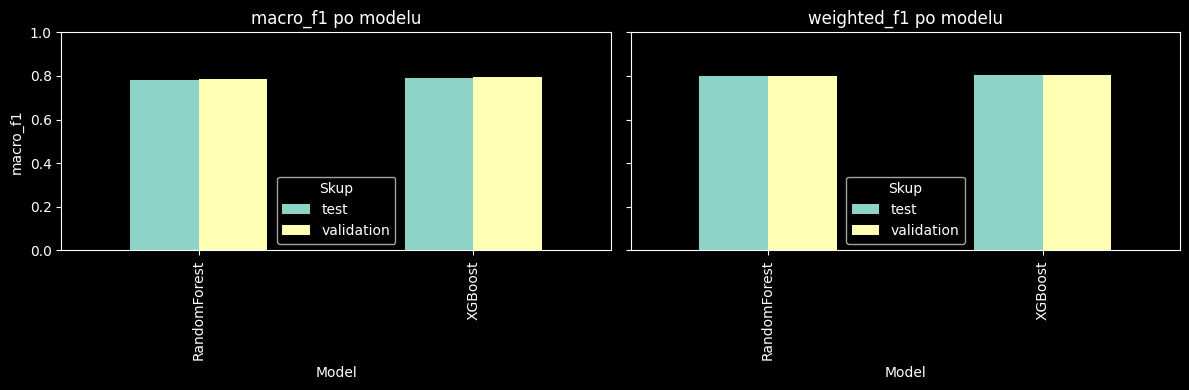

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for idx, metric_col in enumerate(["macro_f1", "weighted_f1"]):
    pivot = classification_metrics_latest.pivot(index="model", columns="split", values=metric_col)
    pivot.plot(kind="bar", ax=axes[idx])
    axes[idx].set_title(f"{metric_col} po modelu")
    axes[idx].set_xlabel("Model")
    axes[idx].set_ylabel(metric_col)
    axes[idx].set_ylim(0, 1)
    axes[idx].legend(title="Skup")
plt.tight_layout()

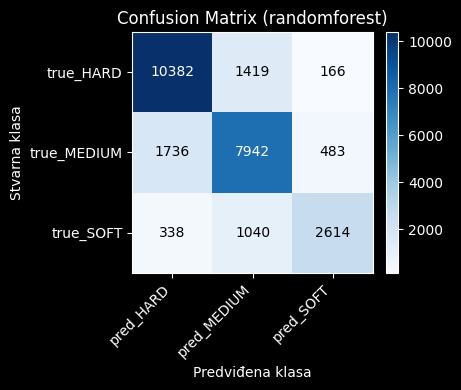

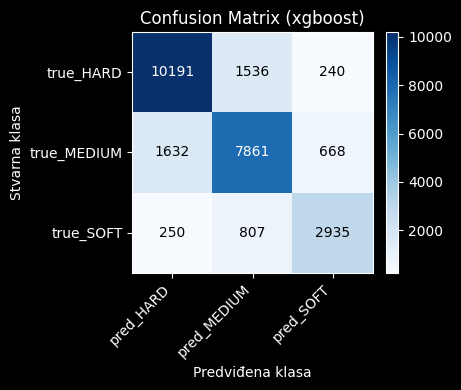

In [19]:
if latest_classification_run_id is not None:
    cm_files = sorted((results_path / "classification/runs").glob(f"confusion_matrix_test_*__{latest_classification_run_id}.csv"))
else:
    cm_files = sorted((results_path / "classification").glob("confusion_matrix_test_*.csv"))

if not cm_files:
    print("Nema confusion matrix fajlova za poslednji run.")

for cm_file in cm_files:
    cm_df = pd.read_csv(cm_file, index_col=0)

    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm_df.values, cmap="Blues")
    ax.set_xticks(np.arange(cm_df.shape[1]))
    ax.set_yticks(np.arange(cm_df.shape[0]))
    ax.set_xticklabels(cm_df.columns, rotation=45, ha="right")
    ax.set_yticklabels(cm_df.index)

    threshold = cm_df.values.max() * 0.5 if cm_df.values.size else 0
    for i in range(cm_df.shape[0]):
        for j in range(cm_df.shape[1]):
            value = int(cm_df.iat[i, j])
            color = "white" if value > threshold else "black"
            ax.text(j, i, str(value), ha="center", va="center", color=color, fontsize=10)

    model_label = cm_file.stem.replace("confusion_matrix_test_", "")
    model_label = model_label.split("__")[0]
    ax.set_title(f"Confusion Matrix ({model_label})")
    ax.set_xlabel("Predviđena klasa")
    ax.set_ylabel("Stvarna klasa")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

### 5.2 Značajnost obeležja (Feature Importance)

Prikaz relativnog doprinosa svakog obeležja pri klasifikaciji tipa gume.
RandomForest i XGBoost pružaju različite poglede na značajnost obeležja.

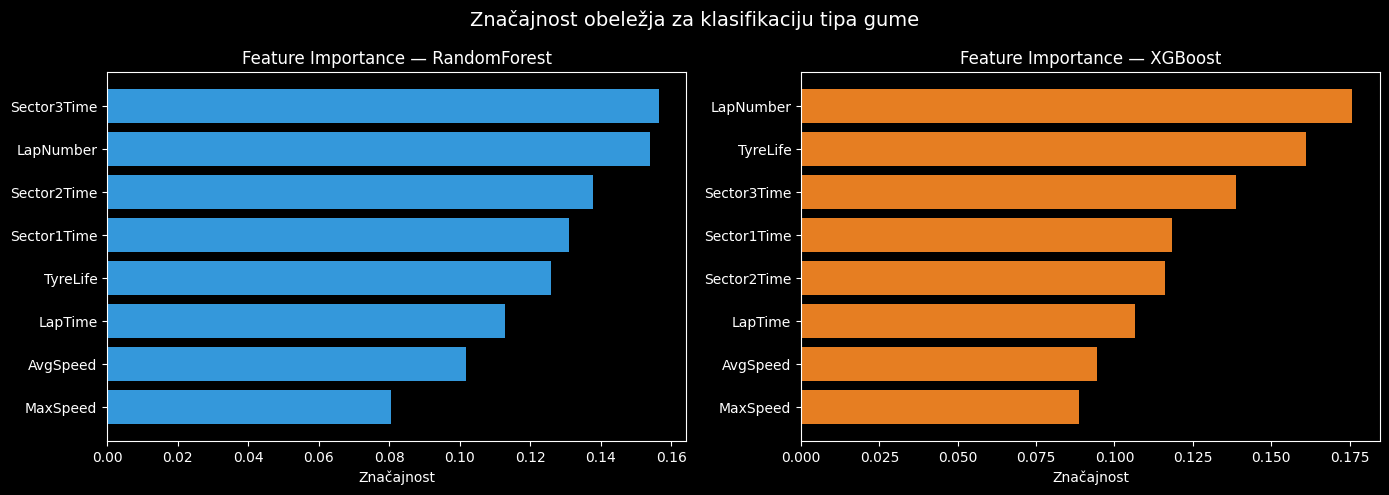

In [20]:
from sklearn.ensemble import RandomForestClassifier as _RFC
from sklearn.model_selection import train_test_split as _tts
from sklearn.preprocessing import LabelEncoder as _LE
from xgboost import XGBClassifier as _XGB
from src.modeling import FEATURE_COLUMNS

fi_subset = processed_laps.dropna(subset=FEATURE_COLUMNS + ["Compound"]).copy()
fi_target = fi_subset["Compound"].astype(str)
fi_train_val, _ = _tts(fi_subset, test_size=0.2, random_state=42, stratify=fi_target)
fi_y_tv = fi_train_val["Compound"].astype(str)
fi_train, _ = _tts(fi_train_val, test_size=0.25, random_state=42, stratify=fi_y_tv)

X_train_fi = fi_train[FEATURE_COLUMNS]
y_train_fi = fi_train["Compound"].astype(str)

rf = _RFC(n_estimators=800, max_depth=50, min_samples_split=2, min_samples_leaf=1,
          max_features=0.75, criterion="entropy",
          random_state=42, n_jobs=-1, class_weight="balanced_subsample")
rf.fit(X_train_fi, y_train_fi)

le = _LE()
y_train_enc = le.fit_transform(y_train_fi)
xgb = _XGB(objective="multi:softprob", eval_metric="mlogloss", n_estimators=1000,
            max_depth=12, learning_rate=0.1, subsample=0.9, colsample_bytree=1.0,
            min_child_weight=5, gamma=0, reg_alpha=0.01, reg_lambda=0.5,
            random_state=42, n_jobs=-1)
xgb.fit(X_train_fi, y_train_enc)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for idx, (model, name, color) in enumerate([
    (rf, "RandomForest", "#3498db"),
    (xgb, "XGBoost", "#e67e22"),
]):
    importances = model.feature_importances_
    sorted_idx = np.argsort(importances)
    axes[idx].barh(
        [FEATURE_COLUMNS[i] for i in sorted_idx],
        importances[sorted_idx],
        color=color,
    )
    axes[idx].set_xlabel("Značajnost")
    axes[idx].set_title(f"Feature Importance — {name}")

fig.suptitle("Značajnost obeležja za klasifikaciju tipa gume", fontsize=14)
plt.tight_layout()

### 5.3 Preciznost, odziv i F1 mera po klasi

Prikaz precision, recall i F1 mere za svaku klasu (SOFT, MEDIUM, HARD) na test skupu.
Ovo pokazuje za koji tip gume model najčešće greši i gde ima prostora za poboljšanje.

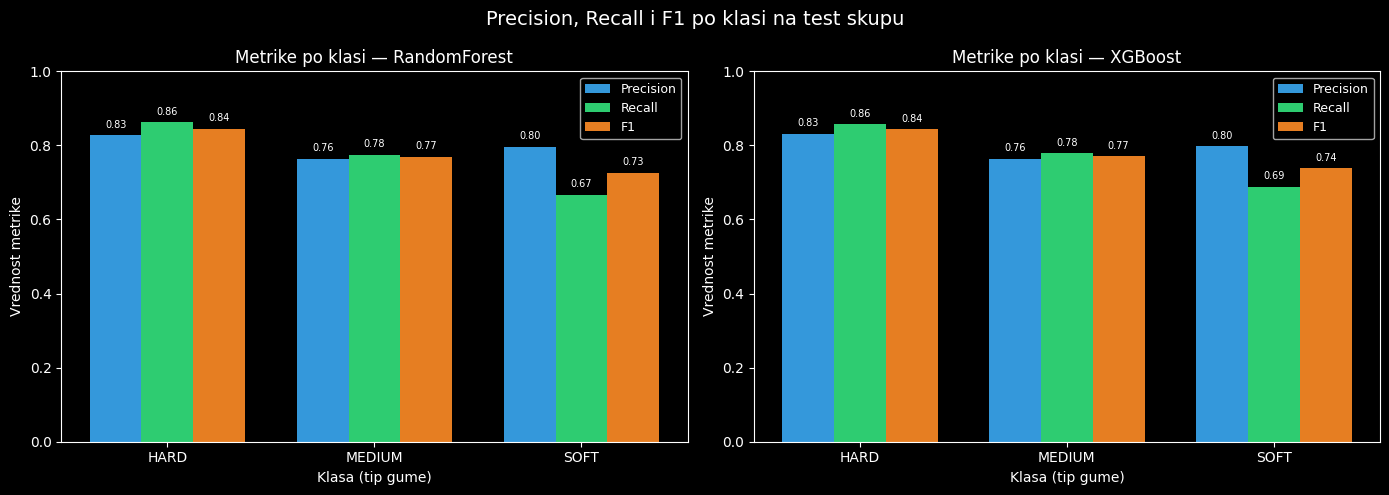

In [21]:
from sklearn.metrics import precision_recall_fscore_support

# Reuse the models already trained in Section 5.2 (rf, xgb, fi_subset)
fi_target_all = fi_subset["Compound"].astype(str)
_, fi_test_split = _tts(fi_subset, test_size=0.2, random_state=42, stratify=fi_target_all)
X_test_fi = fi_test_split[FEATURE_COLUMNS]
y_test_fi = fi_test_split["Compound"].astype(str)

class_labels = sorted(y_test_fi.unique())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bar_width = 0.25
metrics_names = ["Precision", "Recall", "F1"]

for idx, (model, name) in enumerate([(rf, "RandomForest"), (xgb, "XGBoost")]):
    if name == "XGBoost":
        y_pred = le.inverse_transform(model.predict(X_test_fi).astype(int))
    else:
        y_pred = model.predict(X_test_fi)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test_fi, y_pred, labels=class_labels, average=None
    )

    x_pos = np.arange(len(class_labels))
    axes[idx].bar(x_pos - bar_width, precision, bar_width, label="Precision", color="#3498db")
    axes[idx].bar(x_pos, recall, bar_width, label="Recall", color="#2ecc71")
    axes[idx].bar(x_pos + bar_width, f1, bar_width, label="F1", color="#e67e22")

    axes[idx].set_xticks(x_pos)
    axes[idx].set_xticklabels(class_labels)
    axes[idx].set_ylim(0, 1)
    axes[idx].set_xlabel("Klasa (tip gume)")
    axes[idx].set_ylabel("Vrednost metrike")
    axes[idx].set_title(f"Metrike po klasi — {name}")
    axes[idx].legend(fontsize=9)

    for j, (p, r, f) in enumerate(zip(precision, recall, f1)):
        axes[idx].text(j - bar_width, p + 0.02, f"{p:.2f}", ha="center", fontsize=7)
        axes[idx].text(j, r + 0.02, f"{r:.2f}", ha="center", fontsize=7)
        axes[idx].text(j + bar_width, f + 0.02, f"{f:.2f}", ha="center", fontsize=7)

fig.suptitle("Precision, Recall i F1 po klasi na test skupu", fontsize=14)
plt.tight_layout()

## 6. Klasterovanje krugova

Klasterovanje grupiše krugove po sličnosti performansi i uslova vožnje, bez direktnog korišćenja ciljnih klasa tokom treniranja.
Rezultati se zatim porede sa kanonskim timskim etiketama radi procene smislenosti dobijenih grupa.


In [22]:
clustering_metrics = evaluate_clustering_models(
    processed_laps,
    output_dir=results_path / "clustering",
    random_state=42,
)
clustering_metrics

,run_id,run_timestamp,model,split,label_basis,feature_space,clustering_strategy,n_clusters,adjusted_rand_index,cluster_purity,model_params
0,20260329T212336651027Z,2026-03-29T21:23:36Z,KMeans,validation,CanonicalTeam,event_compound_zscore_numeric_plus_driver,driver_profile_trainfit_driver_profile_predict,10,0.231965,0.395902,"{""algorithm"": ""lloyd"", ""copy_x"": true, ""init"":..."
1,20260329T212336651027Z,2026-03-29T21:23:36Z,KMeans,test,CanonicalTeam,event_compound_zscore_numeric_plus_driver,driver_profile_trainfit_driver_profile_predict,10,0.230447,0.394719,"{""algorithm"": ""lloyd"", ""copy_x"": true, ""init"":..."
2,20260329T212336651027Z,2026-03-29T21:23:36Z,GMM,validation,CanonicalTeam,event_compound_zscore_numeric_plus_driver,direct_lap_clustering_trainfit_cov_full,10,0.294336,0.482567,"{""covariance_type"": ""full"", ""init_params"": ""km..."
3,20260329T212336651027Z,2026-03-29T21:23:36Z,GMM,test,CanonicalTeam,event_compound_zscore_numeric_plus_driver,direct_lap_clustering_trainfit_cov_full,10,0.290458,0.477612,"{""covariance_type"": ""full"", ""init_params"": ""km..."


In [23]:
clustering_metrics_latest = clustering_metrics.copy()
latest_clustering_run_id = clustering_metrics["run_id"].iloc[0] if "run_id" in clustering_metrics.columns else None

print(f"Run klasterovanja: {latest_clustering_run_id}")
clustering_metrics_latest

Run klasterovanja: 20260329T212336651027Z


,run_id,run_timestamp,model,split,label_basis,feature_space,clustering_strategy,n_clusters,adjusted_rand_index,cluster_purity,model_params
0,20260329T212336651027Z,2026-03-29T21:23:36Z,KMeans,validation,CanonicalTeam,event_compound_zscore_numeric_plus_driver,driver_profile_trainfit_driver_profile_predict,10,0.231965,0.395902,"{""algorithm"": ""lloyd"", ""copy_x"": true, ""init"":..."
1,20260329T212336651027Z,2026-03-29T21:23:36Z,KMeans,test,CanonicalTeam,event_compound_zscore_numeric_plus_driver,driver_profile_trainfit_driver_profile_predict,10,0.230447,0.394719,"{""algorithm"": ""lloyd"", ""copy_x"": true, ""init"":..."
2,20260329T212336651027Z,2026-03-29T21:23:36Z,GMM,validation,CanonicalTeam,event_compound_zscore_numeric_plus_driver,direct_lap_clustering_trainfit_cov_full,10,0.294336,0.482567,"{""covariance_type"": ""full"", ""init_params"": ""km..."
3,20260329T212336651027Z,2026-03-29T21:23:36Z,GMM,test,CanonicalTeam,event_compound_zscore_numeric_plus_driver,direct_lap_clustering_trainfit_cov_full,10,0.290458,0.477612,"{""covariance_type"": ""full"", ""init_params"": ""km..."


### 6.1 Vizualizacija evaluacije klasterovanja (poslednji run)

Prikazane su metrike klasterovanja (`adjusted_rand_index`, `cluster_purity`) i raspodele timova po klasterima.
Vizualizacije služe da procene koliko klasteri prate realne obrasce u podacima.


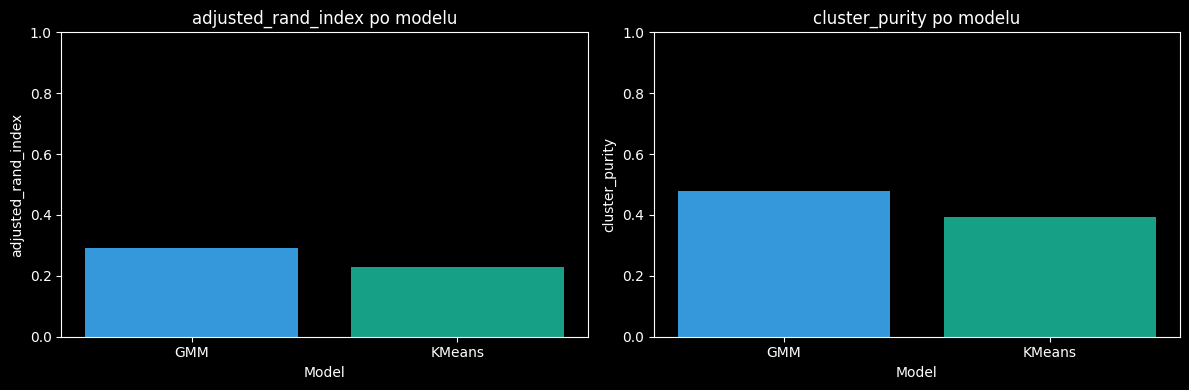

In [24]:
plot_cols = ["adjusted_rand_index", "cluster_purity"]
plot_df = clustering_metrics_latest.copy()
if "split" in plot_df.columns:
    test_df = plot_df[plot_df["split"].astype(str) == "test"].copy()
    if not test_df.empty:
        plot_df = test_df

plot_df = plot_df.groupby("model", as_index=False)[plot_cols].mean()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for idx, metric_col in enumerate(plot_cols):
    axes[idx].bar(plot_df["model"], plot_df[metric_col], color=["#3498db", "#16a085"])
    axes[idx].set_title(f"{metric_col} po modelu")
    axes[idx].set_xlabel("Model")
    axes[idx].set_ylabel(metric_col)
    axes[idx].set_ylim(0, 1)

plt.tight_layout()



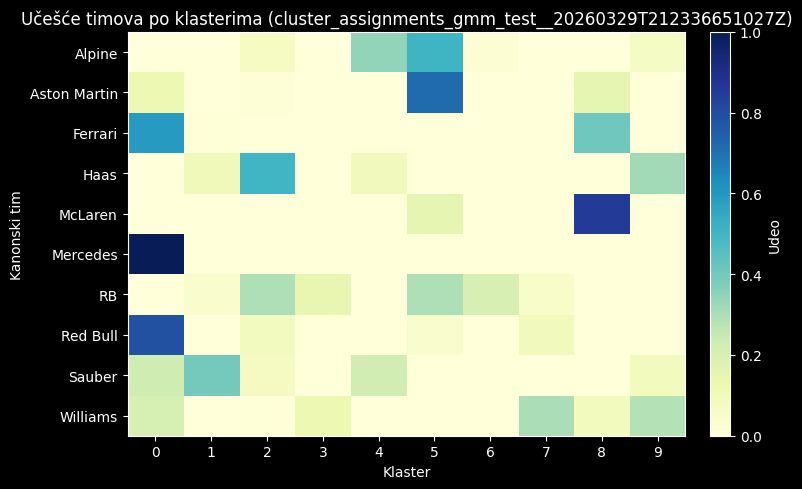

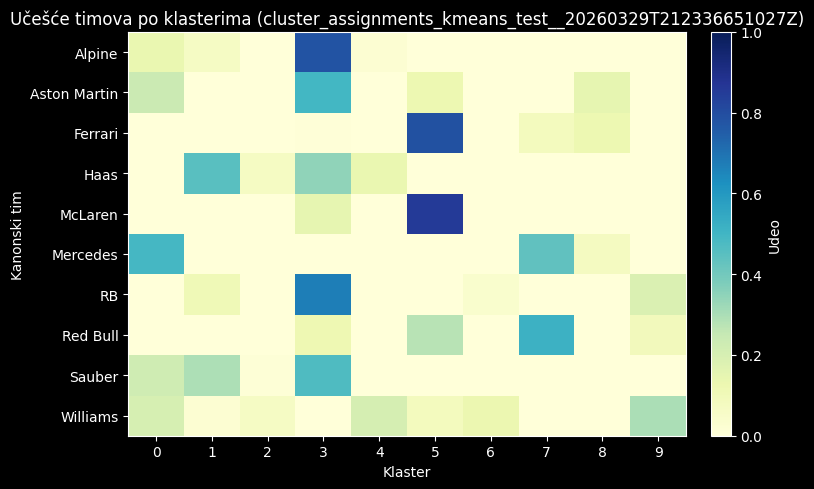

In [25]:
if latest_clustering_run_id is not None:
    assignment_files = sorted((results_path / "clustering/runs").glob(f"cluster_assignments_*_test__{latest_clustering_run_id}.csv"))
    # Fallback za starije run-ove koji imaju samo legacy naziv fajla
    if not assignment_files:
        assignment_files = sorted((results_path / "clustering/runs").glob(f"cluster_assignments_*__{latest_clustering_run_id}.csv"))
else:
    assignment_files = sorted((results_path / "clustering").glob("cluster_assignments_*_test.csv"))
    if not assignment_files:
        assignment_files = sorted((results_path / "clustering").glob("cluster_assignments_*.csv"))

for assignment_file in assignment_files:
    assign_df = pd.read_csv(assignment_file)
    if "CanonicalTeam" not in assign_df.columns:
        continue

    contingency = pd.crosstab(assign_df["CanonicalTeam"], assign_df["cluster"], normalize="index")

    fig, ax = plt.subplots(figsize=(8, 5))
    im = ax.imshow(contingency.values, cmap="YlGnBu", aspect="auto", vmin=0, vmax=1)
    ax.set_xticks(np.arange(contingency.shape[1]))
    ax.set_yticks(np.arange(contingency.shape[0]))
    ax.set_xticklabels(contingency.columns)
    ax.set_yticklabels(contingency.index)
    ax.set_xlabel("Klaster")
    ax.set_ylabel("Kanonski tim")
    ax.set_title(f"Učešće timova po klasterima ({assignment_file.stem})")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Udeo")
    plt.tight_layout()
    plt.show()



### 6.1.1 2D i 3D vizualizacija klastera

Redukcija dimenzionalnosti (PCA) sažima obeležja u 2 ili 3 komponente radi vizualizacije.
Modeli (KMeans i GMM) se fituju na train skupu sa standardizovanim numeričkim obeležjima, a vizualizacija prikazuje test skup.

**Napomena:** Za vizualizaciju se koristi pojednostavljena StandardScaler normalizacija samo na numeričkim obeležjima, bez event/compound z-score i Driver one-hot kodiranja. Potpuni pipeline sa svim koracima koristi se u evaluaciji (sekcija 6).

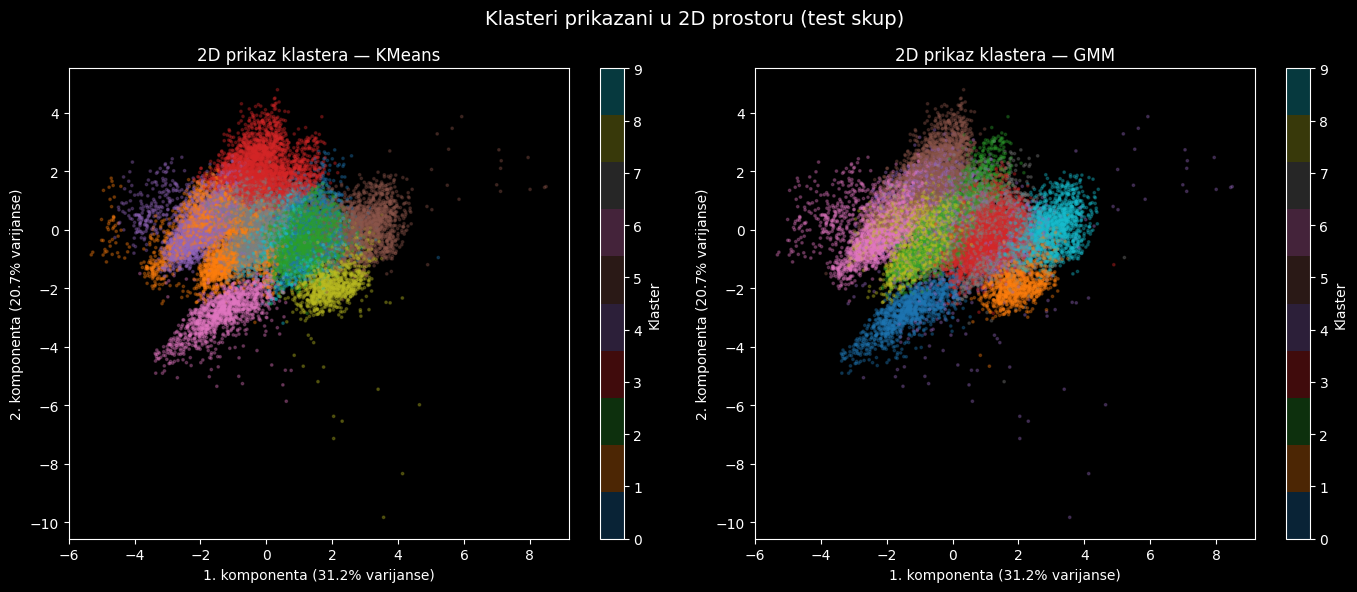

In [26]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler as _StdScaler
from sklearn.cluster import KMeans as _KM
from sklearn.mixture import GaussianMixture as _GMM
from src.modeling import FEATURE_COLUMNS

subset_cl = processed_laps.dropna(subset=FEATURE_COLUMNS + ["CanonicalTeam"]).copy()
y_cl = subset_cl["CanonicalTeam"].astype(str)
train_val_cl, test_cl = _tts(subset_cl, test_size=0.2, random_state=42, stratify=y_cl)

# Fit scaler na train, transform oba skupa
scaler = _StdScaler()
X_train_scaled = scaler.fit_transform(train_val_cl[FEATURE_COLUMNS].values)
X_scaled = scaler.transform(test_cl[FEATURE_COLUMNS].values)

n_clusters = y_cl.nunique()
km = _KM(n_clusters=n_clusters, n_init=40, random_state=42)
km.fit(X_train_scaled)
km_labels = km.predict(X_scaled)

gmm = _GMM(n_components=n_clusters, covariance_type="full", reg_covar=1e-4,
            n_init=5, init_params="kmeans", max_iter=300, random_state=42)
gmm.fit(X_train_scaled)
gmm_labels = gmm.predict(X_scaled)

pca_2d = PCA(n_components=2)
pca_2d.fit(X_train_scaled)
X_2d = pca_2d.transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for idx, (labels, model_name) in enumerate([(km_labels, "KMeans"), (gmm_labels, "GMM")]):
    scatter = axes[idx].scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap="tab10", alpha=0.3, s=3)
    axes[idx].set_xlabel(f"1. komponenta ({pca_2d.explained_variance_ratio_[0]:.1%} varijanse)")
    axes[idx].set_ylabel(f"2. komponenta ({pca_2d.explained_variance_ratio_[1]:.1%} varijanse)")
    axes[idx].set_title(f"2D prikaz klastera — {model_name}")
    fig.colorbar(scatter, ax=axes[idx], label="Klaster")

fig.suptitle("Klasteri prikazani u 2D prostoru (test skup)", fontsize=14)
plt.tight_layout()

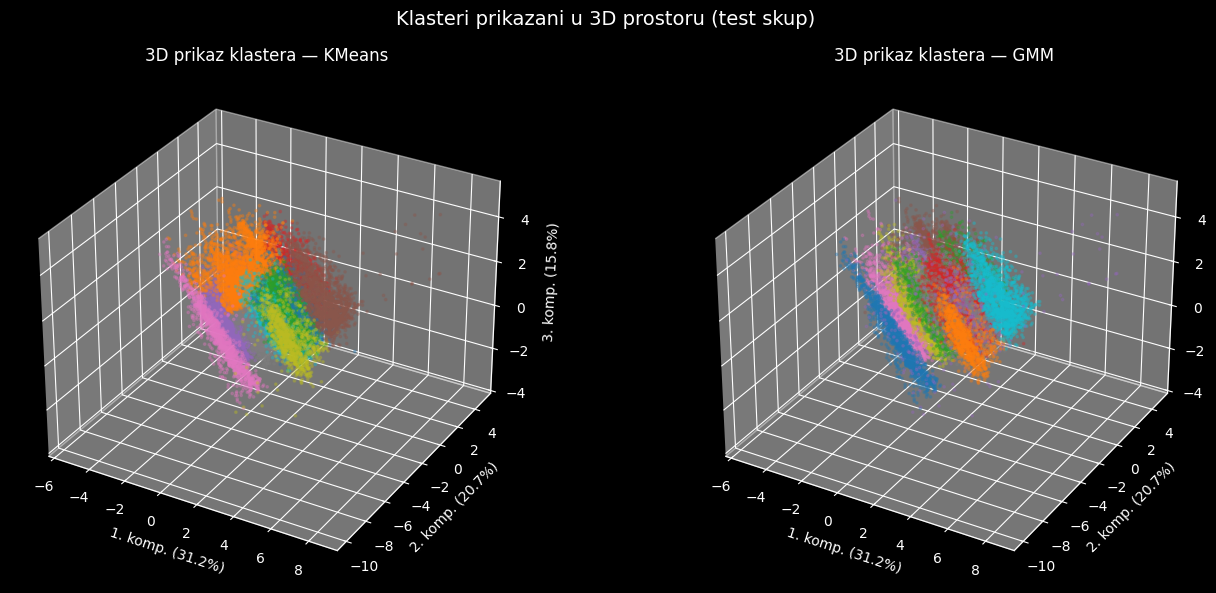

In [27]:
pca_3d = PCA(n_components=3)
pca_3d.fit(X_train_scaled)
X_3d = pca_3d.transform(X_scaled)

fig = plt.figure(figsize=(14, 6))
for idx, (labels, model_name) in enumerate([(km_labels, "KMeans"), (gmm_labels, "GMM")]):
    ax = fig.add_subplot(1, 2, idx + 1, projection="3d")
    scatter = ax.scatter(X_3d[:, 0], X_3d[:, 1], X_3d[:, 2],
                         c=labels, cmap="tab10", alpha=0.3, s=3)
    ax.set_xlabel(f"1. komp. ({pca_3d.explained_variance_ratio_[0]:.1%})")
    ax.set_ylabel(f"2. komp. ({pca_3d.explained_variance_ratio_[1]:.1%})")
    ax.set_zlabel(f"3. komp. ({pca_3d.explained_variance_ratio_[2]:.1%})")
    ax.set_title(f"3D prikaz klastera — {model_name}")

fig.suptitle("Klasteri prikazani u 3D prostoru (test skup)", fontsize=14)
plt.tight_layout()

### 6.1.2 Analiza optimalnog broja klastera (Elbow i Silhouette)

Elbow metoda prikazuje kako se ukupna unutar-klasterska varijansa (inertia) smanjuje sa povećanjem broja klastera — „lakat" ukazuje na optimalan broj.
Silhouette score meri koliko su tačke dobro raspoređene u svoje klastere (vrednosti bliže 1 su bolje).

Analiza je urađena na train skupu (poduzorkovanom na 20000 redova za efikasnost), sa StandardScaler normalizacijom fitovanom na train.
Rezultati potvrđuju da silhouette favorizuje manji broj klastera (k=3), dok je k=10 izabrano na osnovu broja timova.

Optimalni k po silhouette: 25 (score=0.2344)
Silhouette za k=10: 0.2273


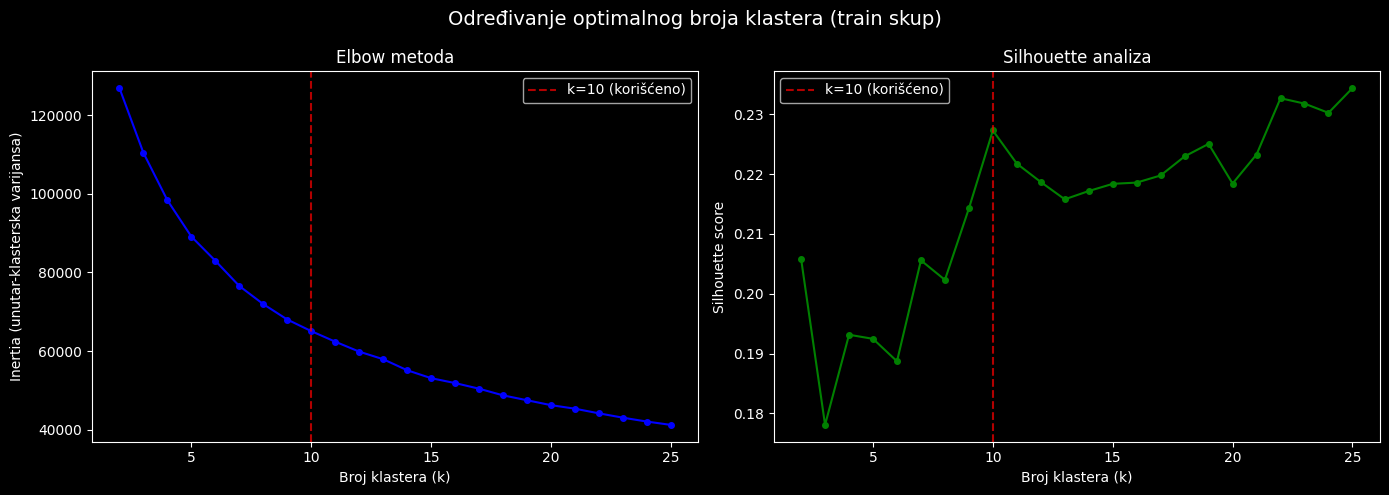

In [28]:
from sklearn.metrics import silhouette_score

# Silhouette i Elbow analiza na train skupu (fitovan scaler)
n_sample = min(20000, len(X_train_scaled))
rng = np.random.RandomState(42)
sample_idx = rng.choice(len(X_train_scaled), size=n_sample, replace=False)
X_sample = X_train_scaled[sample_idx]

k_range = range(2, 26)
inertias = []
silhouette_scores = []

for k in k_range:
    km_temp = _KM(n_clusters=k, n_init=10, random_state=42)
    km_temp.fit(X_sample)
    inertias.append(km_temp.inertia_)
    silhouette_scores.append(silhouette_score(X_sample, km_temp.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
axes[0].plot(list(k_range), inertias, "b-o", markersize=4)
axes[0].axvline(x=10, color="red", linestyle="--", alpha=0.7, label="k=10 (korišćeno)")
axes[0].set_xlabel("Broj klastera (k)")
axes[0].set_ylabel("Inertia (unutar-klasterska varijansa)")
axes[0].set_title("Elbow metoda")
axes[0].legend()

# Silhouette plot
axes[1].plot(list(k_range), silhouette_scores, "g-o", markersize=4)
axes[1].axvline(x=10, color="red", linestyle="--", alpha=0.7, label="k=10 (korišćeno)")
axes[1].set_xlabel("Broj klastera (k)")
axes[1].set_ylabel("Silhouette score")
axes[1].set_title("Silhouette analiza")
axes[1].legend()

best_k = list(k_range)[np.argmax(silhouette_scores)]
print(f"Optimalni k po silhouette: {best_k} (score={max(silhouette_scores):.4f})")
print(f"Silhouette za k=10: {silhouette_scores[8]:.4f}")

fig.suptitle("Određivanje optimalnog broja klastera (train skup)", fontsize=14)
plt.tight_layout()

### 6.1.3 Profili performansi timova (radar grafik)

Radar grafik prikazuje prosečne normalizovane vrednosti obeležja za svaki tim.
Ako timovi imaju različite „oblike" profila, to znači da klasteri mogu da uhvate stvarne razlike među njima.

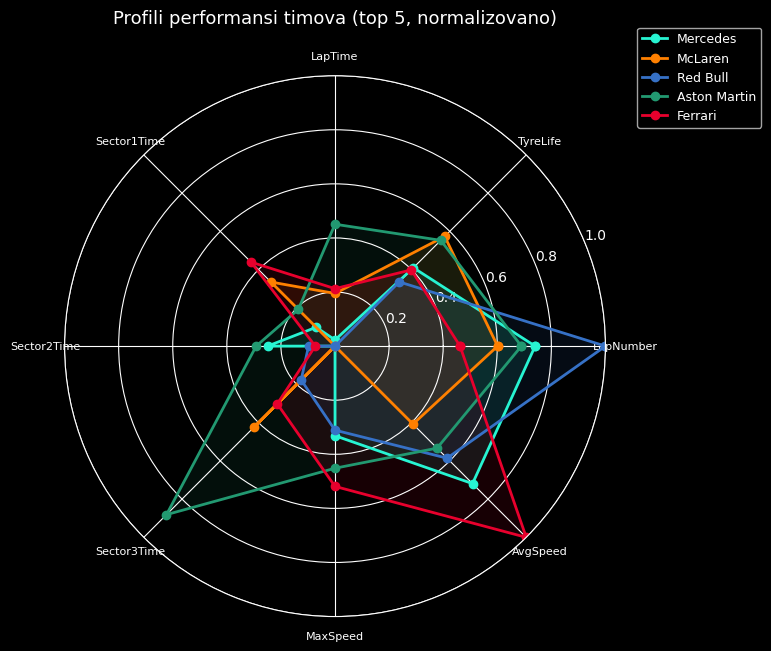

In [38]:
# Use test_cl and FEATURE_COLUMNS from Section 6.1.1
radar_df = test_cl.copy()
radar_df["CanonicalTeam_str"] = radar_df["CanonicalTeam"].astype(str)

# Normalize features to 0-1 range for radar
team_means = radar_df.groupby("CanonicalTeam_str")[FEATURE_COLUMNS].mean()
radar_norm = (team_means - team_means.min()) / (team_means.max() - team_means.min())

# Select top 5 teams by lap count for readability
top_teams = radar_df["CanonicalTeam_str"].value_counts().head(5).index
radar_norm = radar_norm.loc[top_teams]

categories = FEATURE_COLUMNS
n_cats = len(categories)
angles = np.linspace(0, 2 * np.pi, n_cats, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for idx, (team, row) in enumerate(radar_norm.iterrows()):
    color = TEAM_COLORS.get(team, plt.cm.tab10(idx / len(top_teams)))
    values = row.tolist()
    values += values[:1]
    ax.plot(angles, values, "o-", linewidth=2, label=team, color=color)
    ax.fill(angles, values, alpha=0.1, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=8)
ax.set_ylim(0, 1)
ax.set_title("Profili performansi timova (top 5, normalizovano)", fontsize=13, pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=9)
plt.tight_layout()

### 6.1.4 PCA — klasteri vs. stvarni timovi

Poređenje 2D PCA vizualizacije obojene po klasterima (levo) sa istim prikazom obojenim po stvarnim timovima (desno).
Ovo direktno pokazuje koliko dobro klasteri odgovaraju realnim timskim grupama.

In [ ]:
# Reuse X_2d, pca_2d, gmm_labels from Section 6.1.1
team_labels = test_cl["CanonicalTeam"].astype(str).values
unique_teams = sorted(set(team_labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: GMM clusters
scatter1 = axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c=gmm_labels, cmap="tab10", alpha=0.3, s=3)
axes[0].set_xlabel(f"1. komponenta ({pca_2d.explained_variance_ratio_[0]:.1%} varijanse)")
axes[0].set_ylabel(f"2. komponenta ({pca_2d.explained_variance_ratio_[1]:.1%} varijanse)")
axes[0].set_title("GMM klasteri")
fig.colorbar(scatter1, ax=axes[0], label="Klaster")

# Right: true teams with official F1 colors
for team in unique_teams:
    mask = np.array(team_labels) == team
    color = TEAM_COLORS.get(team, "#CCCCCC")
    axes[1].scatter(X_2d[mask, 0], X_2d[mask, 1], c=color, alpha=0.3, s=3, label=team)

axes[1].set_xlabel(f"1. komponenta ({pca_2d.explained_variance_ratio_[0]:.1%} varijanse)")
axes[1].set_ylabel(f"2. komponenta ({pca_2d.explained_variance_ratio_[1]:.1%} varijanse)")
axes[1].set_title("Stvarni timovi (ground truth)")
axes[1].legend(fontsize=7, loc="upper right", ncol=2, title="Tim", markerscale=3)

fig.suptitle("Poređenje: GMM klasteri vs. stvarni timovi u PCA prostoru", fontsize=14)
plt.tight_layout()

### 6.1.5 Profili klastera (centroidi)

Toplotna mapa prosečnih vrednosti obeležja po klasteru (KMeans centroidi).
Prikazuje šta svaki klaster „predstavlja" — npr. jedan klaster može biti brzi timovi na mekim gumama, drugi sporiji timovi na tvrdim gumama.

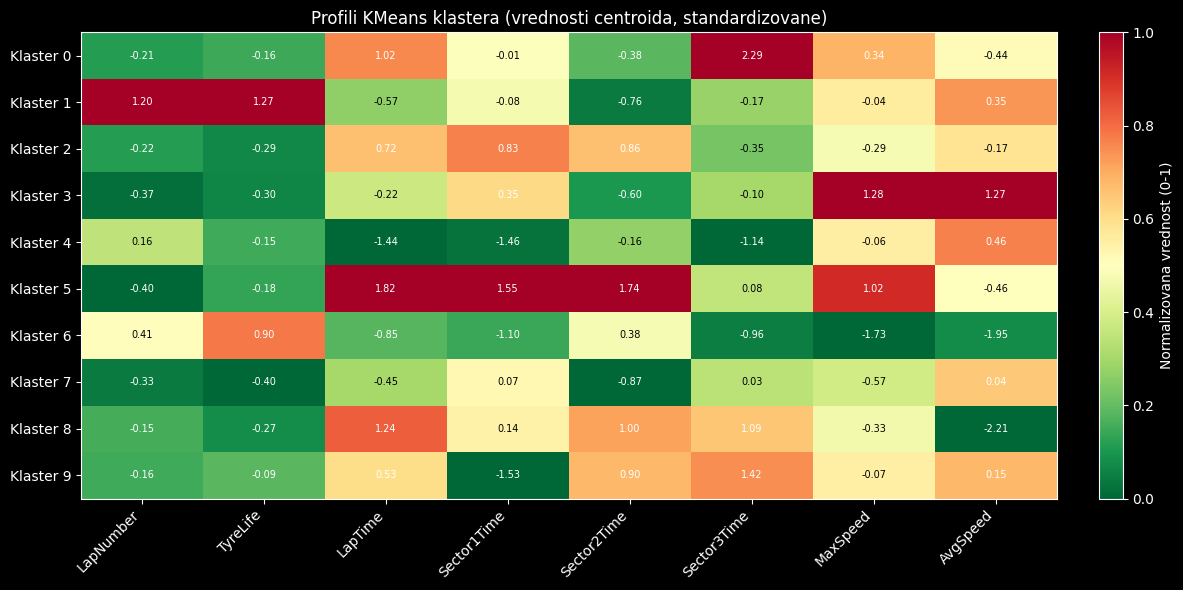

In [31]:
# KMeans centroids from Section 6.1.1 (km object, fitted on X_scaled)
centroids_df = pd.DataFrame(km.cluster_centers_, columns=FEATURE_COLUMNS)

# Normalize centroids to 0-1 per feature for better visualization
centroids_norm = (centroids_df - centroids_df.min()) / (centroids_df.max() - centroids_df.min())

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(centroids_norm.values, cmap="RdYlGn_r", aspect="auto", vmin=0, vmax=1)
ax.set_xticks(np.arange(len(FEATURE_COLUMNS)))
ax.set_yticks(np.arange(len(centroids_norm)))
ax.set_xticklabels(FEATURE_COLUMNS, rotation=45, ha="right")
ax.set_yticklabels([f"Klaster {i}" for i in range(len(centroids_norm))])

for i in range(len(centroids_norm)):
    for j in range(len(FEATURE_COLUMNS)):
        val = centroids_norm.values[i, j]
        color = "white" if val > 0.6 or val < 0.2 else "black"
        ax.text(j, i, f"{centroids_df.values[i, j]:.2f}", ha="center", va="center",
                color=color, fontsize=7)

ax.set_title("Profili KMeans klastera (vrednosti centroida, standardizovane)")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Normalizovana vrednost (0-1)")
plt.tight_layout()

### 6.1.6 Dendrogram sličnosti timova

Hijerarhijsko klasterovanje na osnovu prosečnih profila timova.
Timovi koji se spajaju na manjoj udaljenosti su sličniji po performansama — ovo pokazuje koji timovi su najteži za razdvajanje i da li je k=10 opravdano.

In [ ]:
from scipy.cluster.hierarchy import linkage, dendrogram

# Compute mean standardized features per team
dendro_df = test_cl.copy()
dendro_df["CanonicalTeam_str"] = dendro_df["CanonicalTeam"].astype(str)

team_profiles = dendro_df.groupby("CanonicalTeam_str")[FEATURE_COLUMNS].mean()
team_profiles_scaled = _StdScaler().fit_transform(team_profiles)

Z = linkage(team_profiles_scaled, method="ward")

fig, ax = plt.subplots(figsize=(12, 6))
dendro = dendrogram(Z, labels=team_profiles.index.tolist(), ax=ax, leaf_rotation=45,
                    leaf_font_size=10, color_threshold=0.7 * max(Z[:, 2]))

# Oboji labele listova oficijelnim F1 bojama
xlabels = ax.get_xticklabels()
for label in xlabels:
    team_name = label.get_text()
    label.set_color(TEAM_COLORS.get(team_name, "black"))
    label.set_fontweight("bold")

ax.set_ylabel("Udaljenost (Ward)")
ax.set_title("Dendrogram sličnosti timova na osnovu prosečnih performansi")
plt.tight_layout()

## 7. Optimizacija hiperparametara

Hiperparametri klasifikacionih modela optimizovani su pomoću Optuna (Bayesian TPE) sa 5-fold stratifikovanom unakrsnom validacijom.
Ciljna metrika je **macro F1** (jednako vrednuje sve klase, direktno cilja slabost SOFT klase).
Klasterovanje je optimizovano sistematskim grid pretrazivanjem po prostorima obeležja, broju klastera i parametrima modela.

Ključne intervencije:
- **SMOTE** oversampling za balansiranje klasa u klasifikaciji
- **Sample weights** za XGBoost (uklonjeno ograničenje bez težina)
- **Silhouette/BIC/AIC analiza** za utvrđivanje optimalnog broja klastera
- **PCA analiza** za redukciju dimenzionalnosti u klasterovanju
- **Compound vs. Team ARI** za proveru šta klasteri zapravo hvataju

=== Rezultati optimizacije klasifikacije ===

RandomForest:
  Najbolji parametri: {'n_estimators': 800, 'max_depth': 50, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 0.75, 'class_weight': 'balanced_subsample', 'criterion': 'entropy'}

XGBoost:
  Najbolji parametri: {'n_estimators': 1000, 'max_depth': 12, 'learning_rate': 0.1, 'subsample': 0.9, 'colsample_bytree': 1.0, 'min_child_weight': 5, 'gamma': 0, 'reg_alpha': 0.01, 'reg_lambda': 0.5}



,Bazni macro F1,Optimizovani CV macro F1,Test macro F1,Delta,SMOTE
Model,,,,,
RandomForest,0.7755,0.789991,0.797356,0.021856,True
XGBoost,0.7460,0.792238,0.800442,0.054442,True


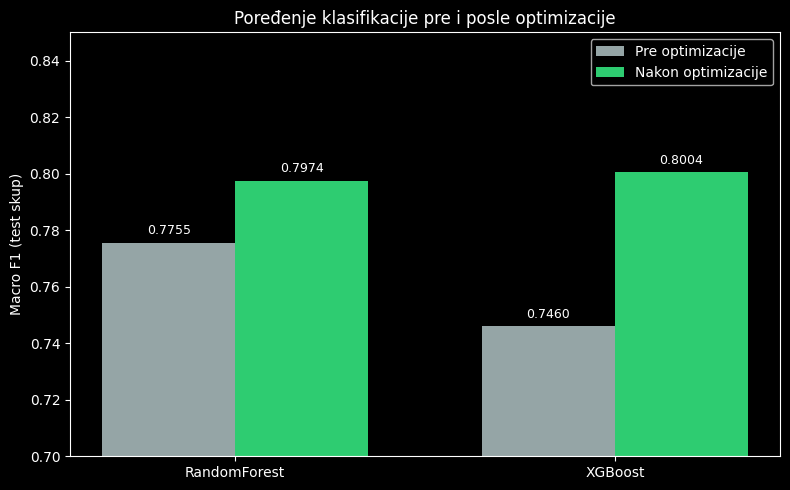

In [33]:
optimization_cls_path = results_path / "optimization/classification_optimization.json"
optimization_clu_path = results_path / "optimization/clustering_optimization.json"

if optimization_cls_path.exists():
    import json as _json
    with optimization_cls_path.open("r", encoding="utf-8") as f:
        opt_cls = _json.load(f)

    print("=== Rezultati optimizacije klasifikacije ===\n")
    # Bazne vrednosti pre optimizacije
    baseline = {"RandomForest": 0.7755, "XGBoost": 0.7460}

    rows = []
    for model_name, res in opt_cls.items():
        bl = baseline.get(model_name, float("nan"))
        rows.append({
            "Model": model_name,
            "Bazni macro F1": bl,
            "Optimizovani CV macro F1": res["best_cv_macro_f1"],
            "Test macro F1": res["test_macro_f1"],
            "Delta": res["test_macro_f1"] - bl,
            "SMOTE": res.get("use_smote", False),
        })
        print(f"{model_name}:")
        print(f"  Najbolji parametri: {res['best_params']}")
        print()

    display(pd.DataFrame(rows).set_index("Model"))

    # Vizualizacija poređenja
    models = list(baseline.keys())
    base_vals = [baseline[m] for m in models]
    opt_vals = [opt_cls[m]["test_macro_f1"] for m in models if m in opt_cls]

    fig, ax = plt.subplots(figsize=(8, 5))
    x = np.arange(len(models))
    width = 0.35
    bars1 = ax.bar(x - width/2, base_vals, width, label="Pre optimizacije", color="#95a5a6")
    bars2 = ax.bar(x + width/2, opt_vals, width, label="Nakon optimizacije", color="#2ecc71")

    ax.set_ylabel("Macro F1 (test skup)")
    ax.set_title("Poređenje klasifikacije pre i posle optimizacije")
    ax.set_xticks(x)
    ax.set_xticklabels(models)
    ax.set_ylim(0.7, 0.85)
    ax.legend()

    for bar in bars1 + bars2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f"{bar.get_height():.4f}", ha="center", va="bottom", fontsize=9)

    plt.tight_layout()
else:
    print("Optimizacija klasifikacije nije pokrenuta. Pokrenite: python -m src.optimization --mode classification")

### 7.1 Optimizacija klasterovanja — Silhouette i BIC/AIC

Rezultati sistematskog pretrazivanja za klasterovanje: silhouette analiza za optimalni k, BIC/AIC za GMM selekciju,
i poređenje prostora obeležja (sa/bez Driver one-hot, sa/bez PCA).

=== Najbolji parametri klasterovanja (po val ARI + purity) ===

KMeans: k=20, space=with_driver, n_init=20
  Val ARI=0.0161, Purity=0.1707

GMM: k=20, space=with_driver_pca, cov=tied, reg=1e-06
  Val ARI=0.3360, Purity=0.6281


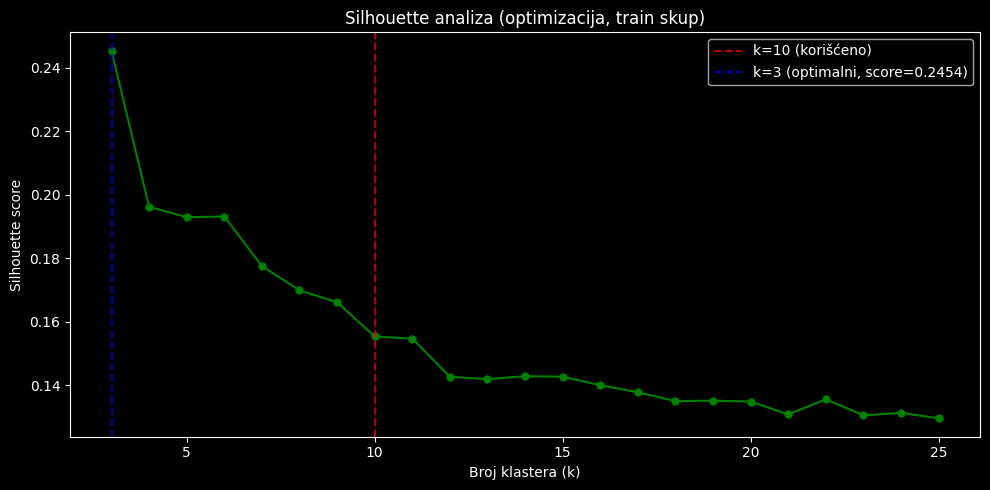

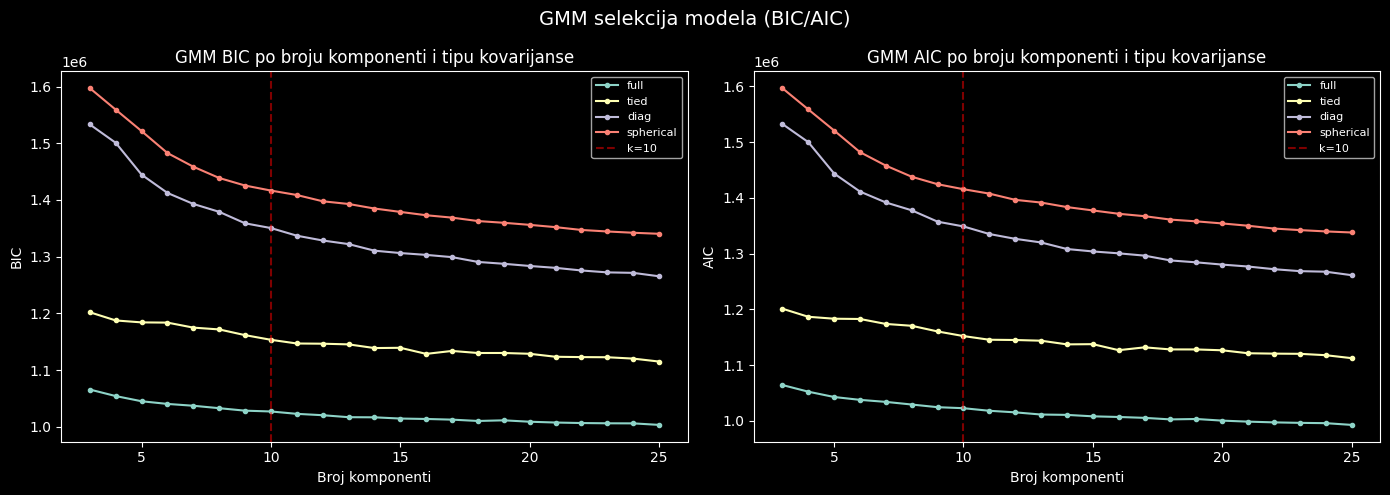

In [34]:
if optimization_clu_path.exists():
    with optimization_clu_path.open("r", encoding="utf-8") as f:
        opt_clu = _json.load(f)

    # Silhouette rezultati
    if "silhouette" in opt_clu:
        sil = opt_clu["silhouette"]
        sil_scores = sil["all_scores"]

        fig, ax = plt.subplots(figsize=(10, 5))
        ks = [s["k"] for s in sil_scores]
        scores = [s["silhouette_score"] for s in sil_scores]
        ax.plot(ks, scores, "g-o", markersize=5)
        ax.axvline(x=10, color="red", linestyle="--", alpha=0.7, label="k=10 (korišćeno)")
        ax.axvline(x=sil["best_k"], color="blue", linestyle="--", alpha=0.7,
                   label=f"k={sil['best_k']} (optimalni, score={sil['best_score']:.4f})")
        ax.set_xlabel("Broj klastera (k)")
        ax.set_ylabel("Silhouette score")
        ax.set_title("Silhouette analiza (optimizacija, train skup)")
        ax.legend()
        plt.tight_layout()

    # BIC/AIC rezultati
    bic_aic_path = results_path / "optimization/gmm_bic_aic_analysis.csv"
    if bic_aic_path.exists():
        bic_df = pd.read_csv(bic_aic_path)

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        for cov_type in bic_df["covariance_type"].unique():
            subset = bic_df[bic_df["covariance_type"] == cov_type]
            axes[0].plot(subset["n_components"], subset["bic"], "-o", markersize=3, label=cov_type)
            axes[1].plot(subset["n_components"], subset["aic"], "-o", markersize=3, label=cov_type)

        for ax, title in zip(axes, ["BIC", "AIC"]):
            ax.axvline(x=10, color="red", linestyle="--", alpha=0.5, label="k=10")
            ax.set_xlabel("Broj komponenti")
            ax.set_ylabel(title)
            ax.set_title(f"GMM {title} po broju komponenti i tipu kovarijanse")
            ax.legend(fontsize=8)

        fig.suptitle("GMM selekcija modela (BIC/AIC)", fontsize=14)
        plt.tight_layout()

    # Najbolji klastering parametri
    if "best_kmeans" in opt_clu and "best_gmm" in opt_clu:
        print("=== Najbolji parametri klasterovanja (po val ARI + purity) ===\n")
        bk = opt_clu["best_kmeans"]
        bg = opt_clu["best_gmm"]
        print(f"KMeans: k={bk['k']}, space={bk['feature_space']}, n_init={bk['n_init']}")
        print(f"  Val ARI={bk['val_ari']:.4f}, Purity={bk['val_purity']:.4f}")
        print(f"\nGMM: k={bg['k']}, space={bg['feature_space']}, cov={bg['covariance_type']}, reg={bg['reg_covar']}")
        print(f"  Val ARI={bg['val_ari']:.4f}, Purity={bg['val_purity']:.4f}")
else:
    print("Optimizacija klasterovanja nije pokrenuta. Pokrenite: python -m src.optimization --mode clustering")

### 7.2 Compound vs. Team ARI analiza

Da li klasteri hvataju timsku strukturu ili tip gume?
Poređenje ARI metrike kada se klasteri evaluiraju naspram timskih labela vs. compound labela (SOFT/MEDIUM/HARD).

**Zaključak:** Compound ARI je blizu nule za sve konfiguracije — klasteri **ne** hvataju tip gume, već zaista grupišu po timskoj pripadnosti. Compound purity od ~0.46 odgovara baznoj stopi (HARD klasa čini ~46% podataka).

,model,space,vat,vpt,vac,vpc,tat,tpt,tac,tpc
0,KMeans,with_driver,0.020579,0.158154,0.001580,0.461924,0.019808,0.159242,0.000965,0.460926
1,GMM,with_driver,0.237343,0.401751,0.002524,0.466244,0.236243,0.401493,0.000966,0.462189
2,KMeans,with_driver_pca,0.020603,0.157810,0.001614,0.461924,0.019683,0.158553,0.000992,0.460926
3,GMM,with_driver_pca,0.190928,0.484747,0.000687,0.463185,0.190532,0.484730,-0.000678,0.460926
4,GMM-tied,with_driver_pca,0.165828,0.413373,0.001970,0.463873,0.163498,0.411940,0.001582,0.460926
5,KMeans,no_driver,0.019680,0.156893,0.002381,0.461924,0.018686,0.157214,0.001391,0.460926
6,GMM,no_driver,0.003134,0.131241,0.001080,0.469990,0.003185,0.130846,0.000005,0.471986


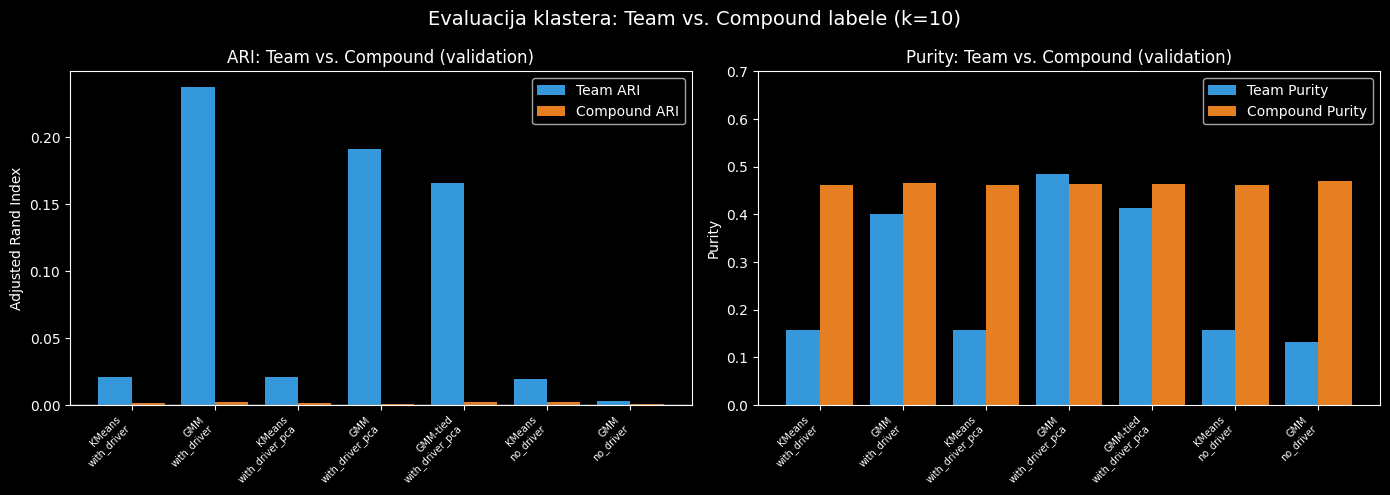

In [35]:
compound_ari_path = results_path / "optimization/compound_vs_team_ari.csv"

if compound_ari_path.exists():
    compound_df = pd.read_csv(compound_ari_path)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Team ARI po konfiguraciji
    labels = [f"{r['model']}\n{r['space']}" for _, r in compound_df.iterrows()]
    x = np.arange(len(labels))

    axes[0].bar(x - 0.2, compound_df["vat"], 0.4, label="Team ARI", color="#3498db")
    axes[0].bar(x + 0.2, compound_df["vac"], 0.4, label="Compound ARI", color="#e67e22")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(labels, fontsize=7, rotation=45, ha="right")
    axes[0].set_ylabel("Adjusted Rand Index")
    axes[0].set_title("ARI: Team vs. Compound (validation)")
    axes[0].legend()
    axes[0].axhline(y=0, color="gray", linestyle="-", alpha=0.3)

    # Purity po konfiguraciji
    axes[1].bar(x - 0.2, compound_df["vpt"], 0.4, label="Team Purity", color="#3498db")
    axes[1].bar(x + 0.2, compound_df["vpc"], 0.4, label="Compound Purity", color="#e67e22")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(labels, fontsize=7, rotation=45, ha="right")
    axes[1].set_ylabel("Purity")
    axes[1].set_title("Purity: Team vs. Compound (validation)")
    axes[1].legend()
    axes[1].set_ylim(0, 0.7)

    fig.suptitle("Evaluacija klastera: Team vs. Compound labele (k=10)", fontsize=14)
    plt.tight_layout()

    display(compound_df)
else:
    print("Compound vs. Team ARI analiza nije dostupna. Pokrenite optimizaciju sa compound evaluacijom.")